In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch,Rectangle
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import multiprocess as mp
import networkx as nx
from multiprocess import Process

# Import the MDP environment from causalAIgym
from causal_gym.envs.mdp_example import MDPExampleSCM, MDPExamplePCH
from causal_gym.envs.dtr_example import DTRExampleSCM, DTRExamplePCH
from causal_gym.core import PolicyType, ActType, ObsType

# Example 8.5: MDP Planning with Dynamic Programming

This notebook implements Example 8.5 from Chapter 8 of the Causal Reinforcement Learning book. This example focuses on solving an MDP using dynamic programming to find the optimal policy in a causal reinforcement learning setting.

In Example 8.5, we consider the MDP environment defined by Equation 7.4, which models an inventory control problem. The key components include:

- Binary state $S_i$ representing inventory level (0=empty, 1=full)
- Binary action $X_i$ representing the decision to restock or not
- Reward $Y_i$ based on the state and action
- Exogenous variables $U_{i,1}, U_{i,2}, U_{i,3}$ representing operation errors, customer demand, and price fluctuations

The structural causal model is defined as:

$$
F_i = \begin{cases}
S_i \gets (S_{i-1} \vee X_{i-1}) \oplus U_{i-1,1} \oplus U_{i-1,2}, \\
X_i \gets S_i \oplus U_{i,1}, \\
Y_i \gets S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}
\end{cases}
$$

Our goal is to find the optimal policy using dynamic programming and verify the results against theoretical expectations.

In [2]:
# Set discount factor as per Example 8.5
GAMMA = 0.9
# Maximum number of steps per episode
MAX_STEPS = 1000
# Number of samples for each experiment
N_SAMPLES = 2000

## 1. Implementing the MDP Environment

First, let's explore the MDP environment from the causalgym. The implementation follows the SCM defined in Example 8.5. We'll create functions to run episodes with different policies."
   

In [ ]:
# Function to run a single episode with a given policy
def run_episode_with_policy(policy, seed=None):
    '''
    Args:
        policy: Function that takes state as input and returns action
        seed: Random seed for reproducibility
    Returns:
        Tuple of (discounted_reward, states, actions, rewards)
    '''
    env = MDPExamplePCH(max_step=MAX_STEPS)
    s, _ = env.reset(seed=seed)
    
    # Track states, actions, rewards
    states = [s]
    actions = []
    rewards = []
    done = False
    discounted_reward = 0
    step = 0
    
    while not done and step < MAX_STEPS:
        # Execute policy intervention
        s, y, _, done, _ = env.do(policy(s))
        
        # Update tracking variables
        actions.append(policy(states[-1]))
        states.append(s)
        rewards.append(y)
        
        # Update discounted reward
        discounted_reward = discounted_reward * GAMMA + y
        step += 1
        
    return discounted_reward, states, actions, rewards

In [3]:
# Function to run the behavioral policy
def run_episode_behavioral(seed=None):
    env = MDPExamplePCH(max_step=MAX_STEPS)
    s, _ = env.reset(seed=seed)
    done = False
    discounted_reward = 0
    rewards = []
    while not done:
        # Use behavioral policy ('see' mode)
        _, s, y, _, done, _ = env.see()
        rewards.append(y)
        discounted_reward = discounted_reward * GAMMA + y
    return discounted_reward, [], [], rewards

## 2. Defining Different Policies

We'll define several policies to evaluate and compare:

1. **Always choose X=0**: Never restock regardless of state
2. **Always choose X=1**: Always restock regardless of state
3. **Match state policy (X=S)**: Restock only when inventory is full (this is the optimal policy according to Example 8.5)
4. **Opposite state policy (X≠S)**: Restock only when inventory is empty

In [4]:
# Define different policies for evaluation
def always_zero_policy(state):
    return 0

def always_one_policy(state):
    return 1

def match_state_policy(state):
    return state

def opposite_state_policy(state):
    return 1 - state

## 3. Evaluating Policies

We'll evaluate each policy by running multiple episodes and computing the average rewards

In [5]:
# Function to evaluate a policy using parallel processing
def evaluate_policy(policy, policy_name):
    manager = mp.Manager()
    results = manager.list()
    processes = []
    
    # Create and start processes
    for i in range(N_SAMPLES):
        p = Process(target=lambda: results.append(run_episode_with_policy(policy, seed=i)))
        processes.append(p)
        p.start()
        
    # Wait for processes to complete
    for p in tqdm(processes, desc=f"Evaluating {policy_name}"):
        p.join()
        
    # Process results
    rewards = []
    daily_profits = []
    for result in results:
        discounted_reward, states, actions, rewards_list = result
        rewards.append(discounted_reward)
        daily_profits.extend(rewards_list)
        
    return {
        'name': policy_name,
        'mean_reward': np.mean(rewards),
        'std_reward': np.std(rewards),
        'daily_profit': np.mean(daily_profits),
        'rewards': rewards,
        'daily_profits': daily_profits
    }

In [6]:
# Evaluate each policy
policy_evaluations = [
    evaluate_policy(always_zero_policy, "do(X=0)"),
    evaluate_policy(always_one_policy, "do(X=1)"),
    evaluate_policy(match_state_policy, "do(X=S)"),
    evaluate_policy(opposite_state_policy, "do(X≠S)")
]

# Also evaluate the behavioral policy
manager = mp.Manager()
results = manager.list()
processes = []
for i in range(N_SAMPLES):
    p = Process(target=lambda: results.append(run_episode_behavioral(seed=i)))
    processes.append(p)
    p.start()
for p in tqdm(processes, desc="Evaluating behavioral policy"):
    p.join()
behavioral_rewards = []
behavioral_daily_profits = []
for result in results:
    discounted_reward, _, _, rewards = result
    behavioral_rewards.append(discounted_reward)
    behavioral_daily_profits.extend(rewards)
behavioral_evaluation = {
    'name': "Behavioral Policy",
    'mean_reward': np.mean(behavioral_rewards),
    'std_reward': np.std(behavioral_rewards),
    'daily_profit': np.mean(behavioral_daily_profits),
    'rewards': behavioral_rewards,
    'daily_profits': behavioral_daily_profits
}
policy_evaluations.append(behavioral_evaluation)

Evaluating behavioral policy: 100%|██████████| 2000/2000 [00:00<00:00, 53269.46it/s]


## 4. Displaying Results

Let's display the results of our policy evaluations compared with the theoretical expectations from Example 8.5.

In [7]:
# Print results for each policy
print("Results for Different Policy Interventions:")
print("-----------------------------------------------------")
print(f"{'Policy':<20} {'Daily Profit':<15} {'Discounted Reward':<20}")
print("-----------------------------------------------------")

# Theoretical values from Example 8.5
theoretical_values = {
    "do(X=S)": {"daily": 0.82, "cumulative": 8.2},
    "Behavioral Policy": {"daily": 0.1, "cumulative": 1.0}
}

# Sort policies by discounted reward (highest first)
sorted_evaluations = sorted(policy_evaluations, key=lambda x: x['mean_reward'], reverse=True)
for eval_data in sorted_evaluations:
    policy_name = eval_data['name']
    daily_profit = eval_data['daily_profit']
    discounted_reward = eval_data['mean_reward']
    
    # Check if we have theoretical values for this policy
    theoretical_str = ""
    if policy_name in theoretical_values:
        theoretical_daily = theoretical_values[policy_name]["daily"]
        theoretical_cum = theoretical_values[policy_name]["cumulative"]
        theoretical_str = f"(Expected: {theoretical_daily:.2f}, {theoretical_cum:.1f})"
    
    print(f"{policy_name:<20} {daily_profit:.4f} {discounted_reward:.4f} {theoretical_str}")

Results for Different Policy Interventions:
-----------------------------------------------------
Policy               Daily Profit    Discounted Reward   
-----------------------------------------------------
do(X=S)              0.8196 8.1735 (Expected: 0.82, 8.2)
do(X=0)              0.4999 5.0053 
do(X=1)              0.2954 2.9719 
do(X≠S)              0.1804 1.8265 
Behavioral Policy    0.1004 1.0335 (Expected: 0.10, 1.0)


## 5. Implementing the Q-Function Calculation

Now let's implement the Q-function calculation using dynamic programming as described in Example 8.5. According to the Bellman equation, the Q-function for state-action pairs is:

$$Q^*(s, a) = R_{exp}(s, a) + \gamma \sum_{s'} T_{exp}(s, a, s') \max_{a'} Q^*(s', a')$$

where:
- $R_{exp}(s, a)$ is the expected reward in state $s$ taking action $a$
- $T_{exp}(s, a, s')$ is the transition probability from state $s$ to $s'$ given action $a$
- $\gamma$ is the discount factor (0.9 in this example)

The transition probabilities and rewards are given in Figure 7.6 in the text

#### transition_probs:
Evaluates a policy by running multiple parallel simulations in the MDP environment. Calculates average rewards, standard deviation, and mean daily profit across all episodes. Returns these metrics in a dictionary to compare policy performance empirically against theoretical expectations.

In [ ]:
# Define transition probabilities based on Figure 7.6
def transition_prob(s, a, s_prime, transitions=None):
    # transition probabilities and rewards using the collected data for example problem 8.10
    if transitions != None:
        return transitions[s][a][s_prime]['prob']
    # transition probabilities and rewards using the collected data for example problem 8.5
    if (s == 0 and a == 0) or (s == 1 and a == 1):
        return 0.18 if s_prime == 0 else 0.82
    else:  # (s == 0 and a == 1) or (s == 1 and a == 0)
        return 0.82 if s_prime == 0 else 0.18

#### reward_f:
Returns the expected immediate reward R(s,a) for taking action a in state s. According to Figure 7.6, matching state and action (s=a) yields reward 0.82, while mismatched pairs yield 0.18. The optional transitions parameter enables custom reward functions.

In [ ]:
# Define rewards based on Figure 7.6
def reward_f(s, a, transitions=None):
    # transition probabilities and rewards using the collected data for example problem 8.10
    if transitions != None:
        # Calculate expected immediate reward
        return sum(transitions[s][a][s_prime]['prob'] * transitions[s][a][s_prime]['reward'] for s_prime in [0, 1])
    # transition probabilities and rewards using the collected data for example problem 8.5
    if (s == 0 and a == 0) or (s == 1 and a == 1):
        return 0.82
    else:  # (s == 0 and a == 1) or (s == 1 and a == 0)
        return 0.18

#### value_iteration:
Implements dynamic programming value iteration to compute the optimal Q-function. Iteratively applies the Bellman equation until convergence:
$$
Q(s,a) = R(s,a) + γ * Σ_s' P(s'|s,a) * max_a' Q(s',a')
$$
Parameters control discount factor (gamma=0.9), convergence criteria, and iteration limits. Returns the converged Q-values that determine the optimal action for each state

In [27]:
# Implement value iteration to compute Q-function
def value_iteration(gamma=0.9, threshold=1e-10, max_iterations=1000, transitions=None):
    # Initialize Q-values
    Q = np.zeros((2, 2))  # Q[s, a]
    iterations = 0
    
    while iterations < max_iterations:
        delta = 0
        old_Q = Q.copy()
        
        # Update Q-values for all state-action pairs
        for s in range(2):
            for a in range(2):
                # Calculate expected value over next states
                expected_future_value = 0
                for s_prime in range(2):
                    # Max Q-value for the next state
                    max_next_q = max(old_Q[s_prime, 0], old_Q[s_prime, 1])
                    expected_future_value += transition_prob(s, a, s_prime, transitions=transitions) * max_next_q
                
                # Update Q-value
                Q[s, a] = reward_f(s, a, transitions=transitions) + gamma * expected_future_value
                
                # Track maximum change
                delta = max(delta, abs(Q[s, a] - old_Q[s, a]))
        
        iterations += 1
        
        # Check convergence
        if delta < threshold:
            print(f"Converged after {iterations} iterations")
            break
            
    return Q

In [9]:
# Compute optimal Q-function
Q_star = value_iteration()

# Display Q-values
print("Optimal Q-function Q*(s, a):")
print("------------------------")
print("State (s) | Action (a) | Q*(s, a)")
print("------------------------")
for s in range(2):
    for a in range(2):
        print(f"{s}         | {a}          | {Q_star[s, a]:.4f}")

# Extract optimal policy
optimal_policy = np.argmax(Q_star, axis=1)
print("\\nOptimal Policy π*(s) = argmax_a Q*(s, a):")
print("------------------------")
print("State (s) | Optimal Action π*(s)")
print("------------------------")
for s in range(2):
    print(f"{s}         | {optimal_policy[s]}")

# Compare with the theoretical policy from Example 8.5 (X_i ← S_i)
theoretical_policy = np.array([0, 1])  # Policy: X_i ← S_i
print("\\nTheoretical Policy from Example 8.5: X_i ← S_i")
print("------------------------")
print("State (s) | Theoretical Action π*(s)")
print("------------------------")
for s in range(2):
    print(f"{s}         | {theoretical_policy[s]}")

# Check if our computed policy matches the theoretical policy
policy_match = np.array_equal(optimal_policy, theoretical_policy)
print(f"\nDoes our computed policy match the theoretical policy? {policy_match}")

Converged after 218 iterations
Optimal Q-function Q*(s, a):
------------------------
State (s) | Action (a) | Q*(s, a)
------------------------
0         | 0          | 8.2000
0         | 1          | 7.5600
1         | 0          | 7.5600
1         | 1          | 8.2000
\nOptimal Policy π*(s) = argmax_a Q*(s, a):
------------------------
State (s) | Optimal Action π*(s)
------------------------
0         | 0
1         | 1
\nTheoretical Policy from Example 8.5: X_i ← S_i
------------------------
State (s) | Theoretical Action π*(s)
------------------------
0         | 0
1         | 1

Does our computed policy match the theoretical policy? True


## 6. Visualizing the Results

Let's create visualizations to better understand our results

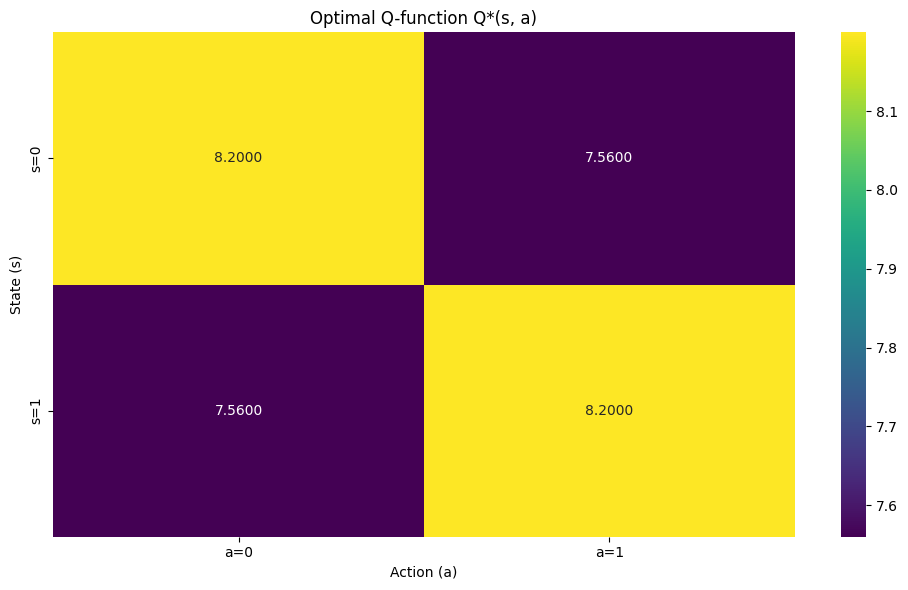

In [10]:
# Visualize the Q-function as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(Q_star, annot=True, cmap='viridis', fmt='.4f',
            xticklabels=['a=0', 'a=1'], yticklabels=['s=0', 's=1'])
plt.title('Optimal Q-function Q*(s, a)')
plt.xlabel('Action (a)')
plt.ylabel('State (s)')
plt.tight_layout()
plt.show()

# Example 8.6: DTR Planning with Dynamic Programing (DP)
This example demonstrates how to solve a 2-stage Dynamic Treatment Regime (DTR) using dynamic programming. In the DTR model, a physician needs to make two sequential treatment decisions based on a patient's condition.

In [12]:
# Set parameters
GAMMA = 0.9
N_SAMPLES = 2000
MAX_STEPS = 1000

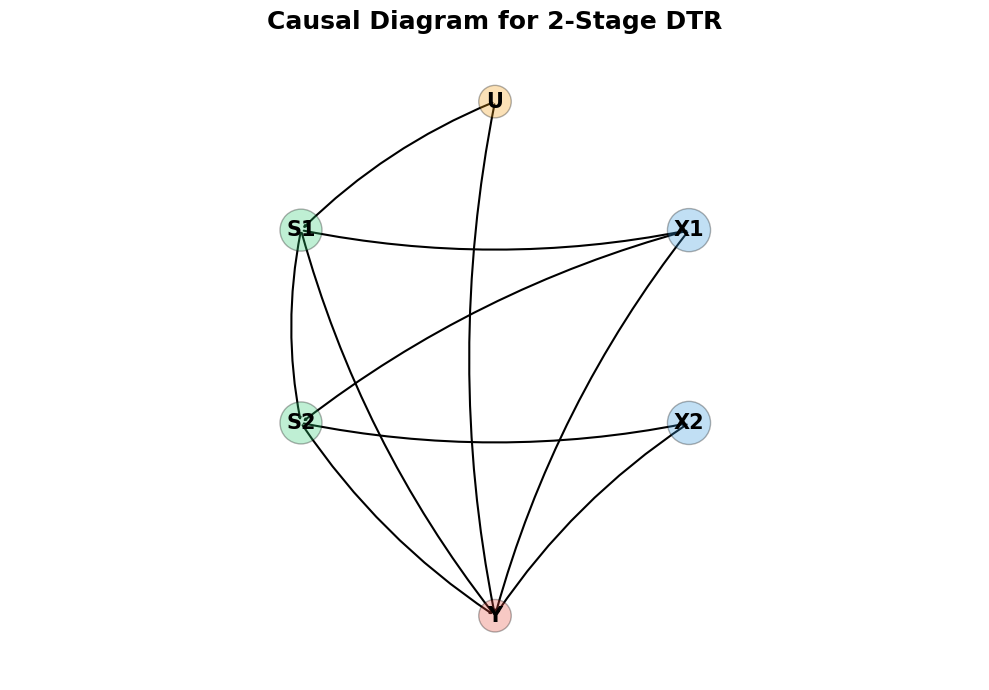

In [13]:
# First, let's create a visualization of the DTR causal diagram
fig, ax = plt.subplots(figsize=(10, 7))

# Define node positions
node_positions = {
    'S1': (0.3, 0.7),
    'X1': (0.7, 0.7),
    'S2': (0.3, 0.4),
    'X2': (0.7, 0.4),
    'Y': (0.5, 0.1),
    'U': (0.5, 0.9)
}

# Draw nodes
for node, pos in node_positions.items():
    if node == 'U':
        color = '#f39c12'  # Yellow for unobserved
        ax.text(pos[0], pos[1], node, ha='center', va='center', fontsize=15,
                fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))
    else:
        if node.startswith('X'):
            color = '#3498db'  # Blue for action
        elif node.startswith('S'):
            color = '#2ecc71'  # Green for state
        else:
            color = '#e74c3c'  # Red for reward
        ax.text(pos[0], pos[1], node, ha='center', va='center', fontsize=15,
                fontweight='bold', bbox=dict(facecolor=color, alpha=0.3, boxstyle="circle"))

# Draw edges
edges = [
    ('S1', 'X1'),
    ('X1', 'S2'),
    ('S1', 'S2'),
    ('S2', 'X2'),
    ('S1', 'Y'),
    ('X1', 'Y'),
    ('S2', 'Y'),
    ('X2', 'Y'),
    ('U', 'S1'),
    ('U', 'Y')
]

for src, dst in edges:
    arrow = FancyArrowPatch(
        node_positions[src], node_positions[dst],
        connectionstyle='arc3,rad=0.1',
        arrowstyle='->,head_width=0.6,head_length=1',
        color='black',
        linewidth=1.5
    )
    ax.add_patch(arrow)

ax.set_title("Causal Diagram for 2-Stage DTR", fontsize=18, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.tight_layout()
plt.show()

### Explanation of the DTR Planning Problem
In Example 8.6, we have a 2-stage DTR model where:


1. $S_1​$ is the initial patient condition

2. $X_1$​ is the first treatment decision

3. $S_2$​ is the patient's response to the first treatment

4. $X_2$​ is the second treatment decision

5. $Y$ is the final outcome (days of abstinence)


We want to find the optimal treatment policy $p^* = (p_1^*, p_2^*)$ that maximizes the expected outcome $\mathbb{E}_p[Y]$

In [ ]:
# Initialize the DTR environment
# We're setting coefficients a1 = a2 = 0 to match Example 8.6
dtr_env = DTRExamplePCH(a1=0, a2=0)

# Let's visualize the optimal policy calculation using dynamic programming
# First, calculate Q(2) values - the value function for the second stage
q2_values = {}

# Compute Q(2) for all state-action combinations
print("Computing Q(2) values for all state-action combinations...")
for s1 in [0, 1]:
    for x1 in [0, 1]:
        for s2 in [0, 1]:
            for x2 in [0, 1]:
                # Estimate the expected reward from observational distribution
                reward_sum = 0
                n_samples = 1000
                for _ in range(n_samples):
                    dtr_env.reset()
                    dtr_env.state = s1
                    _, _, _, _, _ = dtr_env.do(x1)
                    dtr_env.state = s2
                    _, reward, _, _, _ = dtr_env.do(x2)
                    reward_sum += reward
                q2_values[(s1, x1, s2, x2)] = reward_sum / n_samples
                print(f"Q(2)(s1={s1}, x1={x1}, s2={s2}, x2={x2}) = {q2_values[(s1, x1, s2, x2)]:.4f}")

In [14]:
# Now calculate Q(1) values using Q(2)
q1_values = {}
print("\nComputing Q(1) values for all state-action combinations...")
for s1 in [0, 1]:
    for x1 in [0, 1]:
        # For each s1, x1 combination, find the best x2 for each possible s2
        value = 0
        for s2 in [0, 1]:
            # Probability of s2 given s1, x1
            p_s2_given_s1_x1 = 0
            n_samples = 1000
            count_s2 = 0
            for _ in range(n_samples):
                dtr_env.reset()
                dtr_env.state = s1
                next_state, _, _, _, _ = dtr_env.do(x1)
                if next_state == s2:
                    count_s2 += 1
            p_s2_given_s1_x1 = count_s2 / n_samples
            
            # For a given s2, find the optimal x2
            best_x2_value = max(q2_values[(s1, x1, s2, 0)], q2_values[(s1, x1, s2, 1)])
            
            # Add weighted by transition probability
            value += p_s2_given_s1_x1 * best_x2_value
        
        q1_values[(s1, x1)] = value
        print(f"Q(1)(s1={s1}, x1={x1}) = {q1_values[(s1, x1)]:.4f}")


Computing Q(2) values for all state-action combinations...
Q(2)(s1=0, x1=0, s2=0, x2=0) = 0.5080
Q(2)(s1=0, x1=0, s2=0, x2=1) = 0.7100
Q(2)(s1=0, x1=0, s2=1, x2=0) = 0.5240
Q(2)(s1=0, x1=0, s2=1, x2=1) = 0.7260
Q(2)(s1=0, x1=1, s2=0, x2=0) = 0.0000
Q(2)(s1=0, x1=1, s2=0, x2=1) = 0.4920
Q(2)(s1=0, x1=1, s2=1, x2=0) = 0.0000
Q(2)(s1=0, x1=1, s2=1, x2=1) = 0.5070
Q(2)(s1=1, x1=0, s2=0, x2=0) = 0.5180
Q(2)(s1=1, x1=0, s2=0, x2=1) = 0.7030
Q(2)(s1=1, x1=0, s2=1, x2=0) = 0.5130
Q(2)(s1=1, x1=0, s2=1, x2=1) = 0.7120
Q(2)(s1=1, x1=1, s2=0, x2=0) = 0.0000
Q(2)(s1=1, x1=1, s2=0, x2=1) = 0.4980
Q(2)(s1=1, x1=1, s2=1, x2=0) = 0.0000
Q(2)(s1=1, x1=1, s2=1, x2=1) = 0.5190

Computing Q(1) values for all state-action combinations...
Q(1)(s1=0, x1=0) = 0.6848
Q(1)(s1=0, x1=1) = 0.5009
Q(1)(s1=1, x1=0) = 0.7001
Q(1)(s1=1, x1=1) = 0.5071

Optimal Policy:
Stage 1:
  If S1 = 0, then X1 = 0
  If S1 = 1, then X1 = 0
Stage 2:
  If S1 = 0, X1 = 0, S2 = 0, then X2 = 1
  If S1 = 0, X1 = 0, S2 = 1, then X2 = 1
  

#### Define the optimal policy based on Q values

In [ ]:
# Define the optimal policy based on Q values
def optimal_policy_stage1(s1):
    return 0 if q1_values[(s1, 0)] >= q1_values[(s1, 1)] else 1

def optimal_policy_stage2(s1, x1, s2):
    return 0 if q2_values[(s1, x1, s2, 0)] >= q2_values[(s1, x1, s2, 1)] else 1

In [ ]:
# Print the optimal policy
print("\nOptimal Policy:")
print("Stage 1:")
for s1 in [0, 1]:
    print(f"  If S1 = {s1}, then X1 = {optimal_policy_stage1(s1)}")

print("Stage 2:")
for s1 in [0, 1]:
    for x1 in [0, 1]:
        for s2 in [0, 1]:
            print(f"  If S1 = {s1}, X1 = {x1}, S2 = {s2}, then X2 = {optimal_policy_stage2(s1, x1, s2)}")

# Evaluate the expected reward of the optimal policy
def evaluate_optimal_policy():
    rewards = []
    n_samples = 1000
    for _ in range(n_samples):
        dtr_env.reset()
        s1 = dtr_env.state
        x1 = optimal_policy_stage1(s1)
        s2, _, _, _, _ = dtr_env.do(x1)
        x2 = optimal_policy_stage2(s1, x1, s2)
        _, reward, _, _, _ = dtr_env.do(x2)
        rewards.append(reward)
    return np.mean(rewards)

print(f"\nExpected reward of optimal policy: {evaluate_optimal_policy():.4f}")

Mathematical Derivation of Dynamic Programming in DTR
For the 2-stage DTR, the dynamic programming approach calculates:
$$
Q^{(2)}_p(s_1, x_1, s_2, x_2) = \mathbb{E}[Y | s_1, x_1, s_2, x_2]\\
Q^{(1)}_p(s_1, x_1) = \sum_{s_2} Q^{(2)}_p(s_1, x_1, s_2, x_2^*) P(s_2 | s_1, x_1)\\
$$
where $x_2^* = \arg\max_{x_2} Q^{(2)}_p(s_1, x_1, s_2, x_2)$


The optimal policy is given by:
$$
p_1^*(s_1) = \arg\max_{x_1} Q^{(1)}_p(s_1, x_1)\\
p_2^*(s_1, x_1, s_2) = \arg\max_{x_2} Q^{(2)}_p(s_1, x_1, s_2, x_2)\\
$$

# Example 8.10: MDP Observational vs Interventional Distributions
In this example, we explore the difference between observational and interventional distributions in an MDP environment. The observational distribution relates to what happens when we passively observe the environment, while the interventional distribution relates to what happens when we actively intervene.

## Background: MDP Example from Chapter 7 and 8

We'll be working with the MDP environment described in Equation 7.4 and revisited in Examples 8.10-8.13. This environment has a simple structure: 

- Binary state $S_i \in \{0, 1\}$
- Binary action $X_i \in \{0, 1\}$
- Binary reward $Y_i \in \{0, 1\}$
- Exogenous variables $U_{i,1}, U_{i,2}, U_{i,3} \in \{0, 1\}$

The causal mechanisms in the SCM are defined as:

$$
\begin{align}
S_i &\leftarrow (S_{i-1} \vee X_{i-1}) \oplus U_{i-1,1} \oplus U_{i-1,2} \\
X_i &\leftarrow S_i \oplus U_{i,1} \\
Y_i &\leftarrow S_i \oplus X_i \oplus U_{i,1} \oplus U_{i,3}
\end{align}
$$

Where $\oplus$ represents the XOR operation (exclusive OR) and $\vee$ represents the OR operation.

The exogenous variables $U_{i,1}, U_{i,2}, U_{i,3}$ are independent binary variables with:
- $P(U_{i,1} = 1) = 0.9$
- $P(U_{i,2} = 0) = 0.9$
- $P(U_{i,3} = 0) = 0.9$

Our goal is to explore different aspects of this MDP model through observational and interventional distributions, and to understand how this relates to policy learning.

## Example 8.10: Observational Distribution in an MDP

Example 8.10 demonstrates that when learning from observational data in an MDP, we get a specific optimal policy that might not match the true optimal policy.

Let's first create the environment and calculate the observational distribution:

In [ ]:
from examples_implementation import (
    MDP_8_1_3_PCH, AlternativeMDP_1_PCH, AlternativeMDP_2_PCH,
    calculate_transition_and_rewards, calculate_intervention_transition_rewards,
    visualize_state_machine, solve_mdp_value_iteration, compare_mdps,
    visualize_q_values, GAMMA
)


In [ ]:
# Initialize the environment
env = MDP_8_1_3_PCH()

# Calculate observational transition probabilities and rewards
obs_transitions, obs_rewards = calculate_transition_and_rewards(MDP_8_1_3_PCH)

# Visualize the MDP as a finite state machine
visualize_state_machine(obs_transitions, obs_rewards, "Observational MDP (Example 8.10)")

The finite state machine visualization shows the observational dynamics of the MDP. Each arrow represents a transition from one state to another, with the corresponding action (X=0 or X=1), transition probability, and expected reward.

Now, let's solve for the optimal policy using the observational distribution:

In [ ]:
# Solve the MDP based on observational data
q_values_obs, policy_obs = solve_mdp_value_iteration(obs_transitions, obs_rewards, gamma=GAMMA)

# Create a DataFrame for better visualization
q_df = pd.DataFrame(q_values_obs, columns=['a=0', 'a=1'], index=['s=0', 's=1'])
print("Q-values from observational data:")
print(q_df)
print("\nOptimal policy from observational data:")
print(f"For state s=0: {'X=0' if policy_obs[0] == 0 else 'X=1'}")
print(f"For state s=1: {'X=0' if policy_obs[1] == 0 else 'X=1'}")

# Visualize Q-values
plt.figure(figsize=(8, 6))
sns.heatmap(q_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Q-values from Observational Data")
plt.show()

As described in Example 8.10, the optimal policy from observational data is:
- For state s=0: Choose action X=1
- For state s=1: Choose action X=0

This means the policy is $\pi^*_{\text{obs}} \approx X_i \leftarrow \neg S_i$ (where $\neg$ represents negation).

## Example 8.11: Interventional Distribution in an MDP

Example 8.11 shows how the interventional distribution differs from the observational distribution, leading to a different optimal policy.

Let's calculate the interventional distribution by actively intervening in the environment:

In [ ]:
# Calculate interventional transition probabilities and rewards
int_transitions, int_rewards = calculate_intervention_transition_rewards(MDP_8_1_3_PCH)

# Visualize the interventional MDP
visualize_state_machine(int_transitions, int_rewards, "Interventional MDP (Example 8.11)")

Now, let's solve for the optimal policy using the interventional distribution:

In [ ]:
# Solve the MDP based on interventional data
q_values_int, policy_int = solve_mdp_value_iteration(int_transitions, int_rewards, gamma=GAMMA)

# Create a DataFrame for better visualization
q_df = pd.DataFrame(q_values_int, columns=['a=0', 'a=1'], index=['s=0', 's=1'])
print("Q-values from interventional data:")
print(q_df)
print("\nOptimal policy from interventional data:")
print(f"For state s=0: {'X=0' if policy_int[0] == 0 else 'X=1'}")
print(f"For state s=1: {'X=0' if policy_int[1] == 0 else 'X=1'}")

# Visualize Q-values
plt.figure(figsize=(8, 6))
sns.heatmap(q_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Q-values from Interventional Data")
plt.show()

From the interventional data, we get a different optimal policy:
- For state s=0: Choose action X=0
- For state s=1: Choose action X=1

This means the policy is $\pi^*_{\text{exp}} \approx X_i \leftarrow S_i$ (the agent's action matches the state).

According to Example 8.11, the interventional distribution leads us to the true optimal policy in the underlying environment, which is $\pi^*_{\text{exp}} \approx X_i \leftarrow S_i$. This policy yields a higher expected reward when deployed in the actual environment, as shown in the Q-values.

This difference between the observational and interventional distributions demonstrates that just observing an environment without actively experimenting in it can lead to suboptimal policies.

## Example 8.12: Observational ≠⇒ Interventional

Example 8.12 introduces an alternative MDP environment (denoted as $M^{(1)}$) that generates the same observational distribution as the original environment ($M^*$) but has a different interventional distribution.

The alternative MDP has causal mechanisms defined as:

$
\begin{align}
S_i &\leftarrow S_{i-1} \oplus U_{i-1,2} \\
X_i &\leftarrow S_i \oplus U_{i,1} \\
Y_i &\leftarrow U_{i,3}
\end{align}
$

Let's implement this alternative MDP and compare it with the original one:

In [ ]:
# Compare the original MDP with the alternative MDP from Example 8.12
comparison_results = compare_mdps(MDP_8_1_3_PCH, AlternativeMDP_1_PCH)

# Extract results
obs_transitions_original, obs_transitions_alt = comparison_results['obs_transitions']
obs_rewards_original, obs_rewards_alt = comparison_results['obs_rewards']
int_transitions_original, int_transitions_alt = comparison_results['int_transitions']
int_rewards_original, int_rewards_alt = comparison_results['int_rewards']
q_values_obs_original, q_values_obs_alt = comparison_results['q_values_obs']
q_values_int_original, q_values_int_alt = comparison_results['q_values_int']

Let's analyze the results to verify that $M^*$ and $M^{(1)}$ have the same observational distribution but different interventional distributions:


In [ ]:
# Visualize Q-values to check the claims in Example 8.12
visualize_q_values(
    q_values_obs_original, 
    q_values_obs_alt,
    "Q-values from Observational Data ($M^*$)",
    "Q-values from Observational Data ($M^{(1)}$)"
)

visualize_q_values(
    q_values_int_original, 
    q_values_int_alt,
    "Q-values from Interventional Data ($M^*$)",
    "Q-values from Interventional Data ($M^{(1)}$)"
)

The key insight from Example 8.12 is that the observational distribution of an MDP is generally insufficient to uniquely determine the interventional distribution. This means that even with unlimited observational data, we cannot always infer how the environment will respond to our interventions.

Proposition 8.1.1 in the textbook formalizes this insight: For any SCM $M^*$ compatible with the causal diagram of an MDP, there exists another SCM $M^{(1)}$ that generates the same observational distribution but a different interventional distribution.

## Example 8.13: Interventional ≠⇒ Observational

Example 8.13 presents another alternative MDP environment (denoted as $M^{(2)}$) that has the same interventional distribution as the original environment ($M^*$) but a different observational distribution.

The causal mechanisms for $M^{(2)}$ are:

$
\begin{align}
S_i &\leftarrow (S_{i-1} \vee X_{i-1}) \oplus U_{i-1,2} \\
X_i &\leftarrow S_i \oplus U_{i,1} \\
Y_i &\leftarrow S_i \oplus X_i \oplus U_{i,3}
\end{align}
$

Let's implement and analyze this second alternative MDP:

In [ ]:
# Compare the original MDP with the alternative MDP from Example 8.13
comparison_results_2 = compare_mdps(MDP_8_1_3_PCH, AlternativeMDP_2_PCH)

# Extract results
obs_transitions_original, obs_transitions_alt2 = comparison_results_2['obs_transitions']
obs_rewards_original, obs_rewards_alt2 = comparison_results_2['obs_rewards']
int_transitions_original, int_transitions_alt2 = comparison_results_2['int_transitions']
int_rewards_original, int_rewards_alt2 = comparison_results_2['int_rewards']
q_values_obs_original, q_values_obs_alt2 = comparison_results_2['q_values_obs']
q_values_int_original, q_values_int_alt2 = comparison_results_2['q_values_int']

Let's visualize the results to verify the claims in Example 8.13:

In [ ]:
# Visualize Q-values to check the claims in Example 8.13
visualize_q_values(
    q_values_obs_original, 
    q_values_obs_alt2,
    "Q-values from Observational Data ($M^*$)",
    "Q-values from Observational Data ($M^{(2)}$)"
)

visualize_q_values(
    q_values_int_original, 
    q_values_int_alt2,
    "Q-values from Interventional Data ($M^*$)",
    "Q-values from Interventional Data ($M^{(2)}$)"
)

The key insight from Example 8.13 is the converse of Example 8.12: the interventional distribution does not uniquely determine the observational distribution. This means that even with unlimited interventional data, we cannot always infer how the environment behaves under the natural policy.

Proposition 8.1.2 in the textbook formalizes this insight: For any SCM $M^*$ compatible with the causal diagram of an MDP, there exists another SCM $M^{(2)}$ that generates the same interventional distribution but a different observational distribution.

## Implications for Reinforcement Learning

These examples (8.10-8.13) provide important insights for reinforcement learning:

1. **Observational vs. Interventional Learning**: Learning from purely observational data (off-policy learning) may lead to suboptimal policies compared to learning from interventional data (online learning).

2. **The Causal Hierarchy Theorem in RL**: The relationship between observational and interventional distributions in RL is a manifestation of the Causal Hierarchy Theorem (from Chapter 2). The impossibility results show that there's a strict separation between Layer 1 (observational) and Layer 2 (interventional) of the Pearl Causal Hierarchy.

3. **Need for Causal Knowledge**: Without additional causal knowledge or assumptions about the environment, we cannot generally bridge the gap between observational and interventional distributions.

4. **Structural Causal Models**: The SCM framework provides a more expressive language for describing RL environments compared to standard MDPs, allowing us to reason about different layers of the causal hierarchy.

Let's visualize the relationships between different SCMs and the PCH layers:

In [ ]:
# Create a diagram showing the relationships between different SCMs and the PCH layers
from matplotlib import pyplot as plt
from matplotlib_venn import venn3

plt.figure(figsize=(10, 8))
v = venn3(subsets=(1, 1, 1, 1, 1, 1, 1), set_labels=('', '', ''))

# Remove default labels
for label in v.set_labels:
    if label:
        label.set_text('')

# Set custom labels
v.get_label_by_id('100').set_text('$M^{(1)}$\nSame L1 as $M^*$\nDifferent L2')
v.get_label_by_id('100').set_position((-0.3, 0.3))

v.get_label_by_id('010').set_text('$M^{(2)}$\nSame L2 as $M^*$\nDifferent L1')
v.get_label_by_id('010').set_position((0.7, 0.3))

v.get_label_by_id('001').set_text('Other SCMs')
v.get_label_by_id('001').set_position((0.2, -0.5))

v.get_label_by_id('110').set_text('$M^*$\nOriginal MDP')
v.get_label_by_id('110').set_position((0.2, 0.3))

# Add diagram title and annotations
plt.title('Causal Hierarchy in MDP Environments', fontsize=14)
plt.text(-0.7, 0.8, 'Layer 1 (L1): Observational Distribution', fontsize=12)
plt.text(0.2, 0.8, 'Layer 2 (L2): Interventional Distribution', fontsize=12)
plt.text(0.2, -0.8, 'The Causal Hierarchy Theorem states that Layer 2 information\ncannot be derived from Layer 1 information without additional assumptions', 
         fontsize=10, ha='center')

plt.show()

## Conclusion

The examples we've implemented illustrate the fundamental challenge in reinforcement learning: the gap between observational and interventional distributions. This gap is a manifestation of the Causal Hierarchy Theorem, which states that higher layers of causal knowledge cannot generally be obtained from lower layers without additional assumptions.

Standard MDP approaches often implicitly assume access to interventional data or make assumptions that bridge this gap. By using the formalism of Structural Causal Models, we can more explicitly reason about these different layers of causal information and develop algorithms that appropriately account for the available information.

This highlights the importance of causal reasoning in reinforcement learning and motivates the development of Causal Reinforcement Learning methods that explicitly consider the causal structure of the environment.